In [15]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp

In [16]:
import mesh_generator
import parameter_generator
import Eilenberger_run
import nambu_support

In [17]:
# Define the big grid
ntheta = 20
cutoff = 30.*nambu_support.get_bcs_ratio()
nw = 2000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0*nambu_support.get_bcs_ratio()

temperature = 0.1

self_energy_coefficients = {'Elastic':0.5,'Dynes': 0.0005}
# compute the grid
comp_grid = mesh_generator.get_computation_grid(omega_sampling = nw, theta_sampling = ntheta, cutoff = cutoff, fine_omega_sampling = fine_nw, fine_cutoff = fine_cutoff)
# compute the parameters
params = parameter_generator.get_system_parameters(temperature = temperature, mesh_dictionary = comp_grid, critical_temperature = 1, self_energy_coefficients = self_energy_coefficients, gap_symmetry = 's', vector_potential_params = None)


In [19]:
temps = np.linspace(0.1,1.2,30)
gaps, grs, sigmas = Eilenberger_run.equilibrium_sweep(temperatures = temps, params_dict = params.copy(), meshgrid = comp_grid.copy(), gr0 = None)

first_gap (1.7604117-7.91734e-09j)


100%|██████████| 30/30 [00:05<00:00,  5.41it/s]


[Array(1.7600842-1.2142565e-08j, dtype=complex64), Array(1.759807-1.1584948e-08j, dtype=complex64), Array(1.7595369-8.076833e-09j, dtype=complex64), Array(1.7591385-8.938217e-09j, dtype=complex64), Array(1.758341-4.7962367e-09j, dtype=complex64), Array(1.756722-7.3629067e-09j, dtype=complex64), Array(1.7494111+2.417623e-08j, dtype=complex64), Array(1.7343087+1.4590195e-07j, dtype=complex64), Array(1.7226349+1.9175319e-07j, dtype=complex64), Array(1.710447+1.8289866e-07j, dtype=complex64), Array(1.6777191+9.4617945e-08j, dtype=complex64), Array(1.6587373+1.9398123e-09j, dtype=complex64), Array(1.622245-1.1727277e-08j, dtype=complex64), Array(1.5795035+1.4931054e-08j, dtype=complex64), Array(1.5349996+6.751459e-08j, dtype=complex64), Array(1.4807789+1.7992676e-08j, dtype=complex64), Array(1.4160712-2.4306064e-09j, dtype=complex64), Array(1.3431667-1.9719565e-07j, dtype=complex64), Array(1.2569166-3.303163e-07j, dtype=complex64), Array(1.1543927-3.3486035e-07j, dtype=complex64), Array(1.0

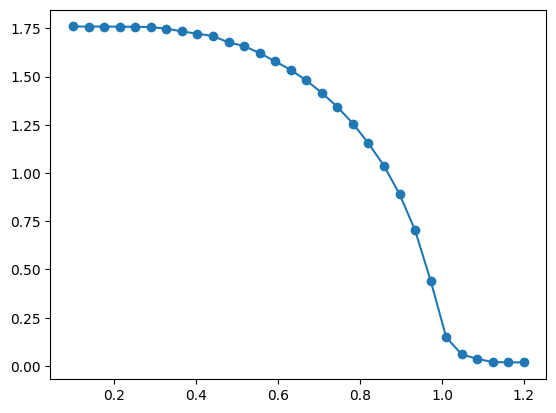

In [21]:
plt.plot(temps,np.abs(gaps[:]), marker = 'o')

### Test a single function run

In [ ]:
omegas = comp_grid['omega_grid']
gr = grs[0]
sigma = sigmas[0]

print(jnp.shape(gr))
print(jnp.shape(sigma))
print(jnp.shape(omegas))

(2, 2, 2200, 20)
(2, 2, 2200)
(2200, 20)


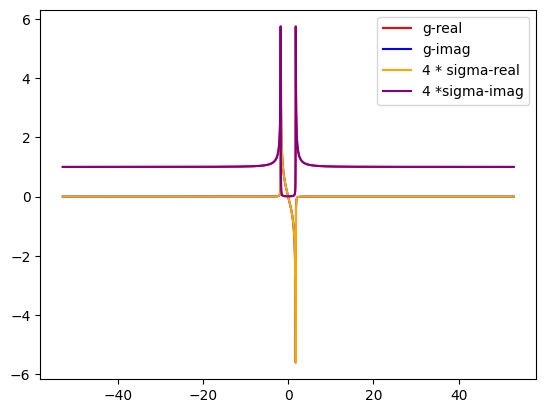

In [30]:
plt.plot(omegas[:,0],jnp.real(gr[0,0,:,0]),'red', label = 'g-real')
plt.plot(omegas[:,0],jnp.imag(gr[0,0,:,0]),'blue', label = 'g-imag')
plt.plot(omegas[:,0],jnp.real(sigma[0,0,:]) * 4,'orange', label = '4 * sigma-real')
plt.plot(omegas[:,0],-jnp.imag(sigma[0,0,:]) * 4,'purple', label = '4 *sigma-imag')
plt.legend()
plt.show()